# Notebook 2 — Validação de Hipóteses e Análise Orçamentária

Objetivo:
Investigar padrões históricos da execução orçamentária federal e sua relação com fatores políticos e eleitorais.


### Mapeamento de Hipóteses

A investigação busca compreender como fatores políticos e eleitorais influenciam o comportamento das despesas públicas federais ao longo do tempo.

- **H1 — Efeito Eleitoral Geral:** O volume de pagamentos aumenta em anos eleitorais quando comparado aos anos não eleitorais?

- **H2 — Tipo de Eleição:** O padrão de gastos difere entre eleições gerais (presidenciais e legislativas) e eleições municipais?

- **H3 — Mudança de Governo:** Diferentes governos apresentam prioridades distintas na alocação de recursos entre grupos de despesas?

- **H4 — Efeito Pós-Eleitoral:** O crescimento das despesas desacelera nos anos imediatamente posteriores às eleições?

- **H5 — Concentração dos Gastos:** A participação relativa dos grupos com maior potencial de impacto político aumenta durante os ciclos eleitorais?

### Validação de Consistência Orçamentária

Além das hipóteses analíticas, foi realizada uma etapa de validação da qualidade dos dados com o objetivo de identificar possíveis anomalias na execução orçamentária.

A verificação concentrou-se na relação entre valores empenhados e pagos, buscando identificar ocorrências em que:

```sql
valor_pago > valor_empenhado
```

Essa análise permite avaliar a consistência dos dados utilizados ao longo do estudo e identificar possíveis efeitos associados a restos a pagar, execução interanual ou diferenças de agregação dos registros orçamentários.

### Objetivo da Etapa

Ao final deste notebook, espera-se identificar quais fatores apresentam maior poder explicativo sobre o comportamento das despesas públicas federais e quais evidências podem contribuir para a modelagem preditiva dos gastos no ciclo eleitoral de 2026.

In [17]:
# Instalação das bibliotecas
%pip install pandas matplotlib seaborn duckdb


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import FuncFormatter


# Configurações globais de visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_theme(style="whitegrid")

# Conexão com o Lakehouse
con = duckdb.connect("../duckdb/lakehouse.duckdb", read_only=True)
print("Conexão com o Lakehouse estabelecida com sucesso!")

Conexão com o Lakehouse estabelecida com sucesso!


## 2. O Impacto dos Ciclos Eleitorais no Orçamento (H1 e H2)

Nesta secção, vamos avaliar se o facto de um ano ser eleitoral (`fl_ano_eleitoral = True`) altera a média de gastos e se o **tipo da eleição** (Geral vs Municipal) dita a prioridade dos pacotes orçamentais.
*(Nota: O ano de 2026 foi excluído por ser um período parcial/em curso).*

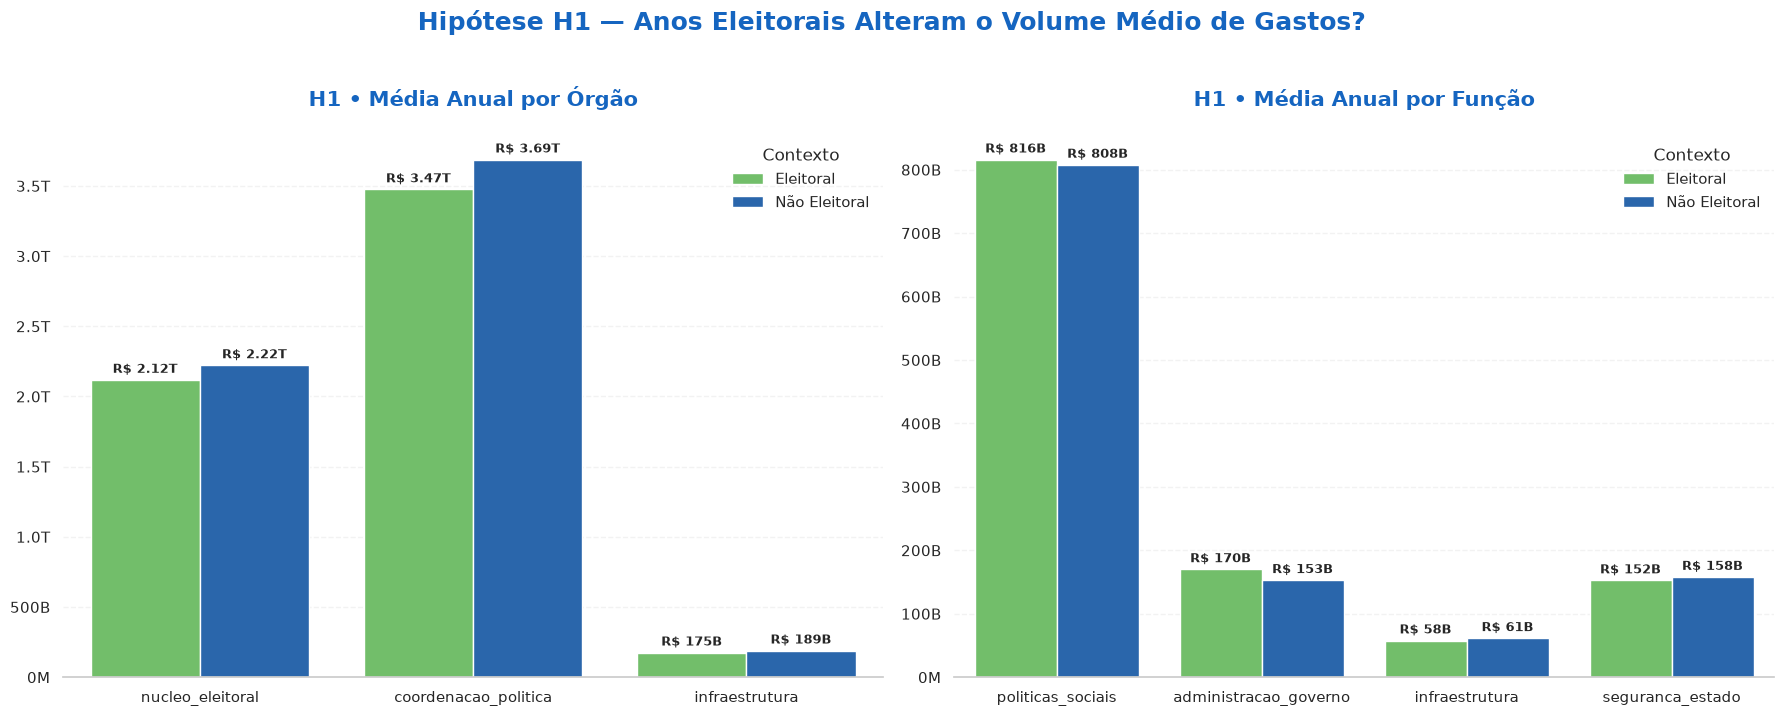

In [19]:
# ==========================
# DADOS H1
# ==========================

df_h1_orgao = con.sql("""
SELECT
    ano,
    pacote,
    CASE
        WHEN tipo_eleicao IN ('Geral', 'Municipal')
            THEN 'Eleitoral'
        ELSE 'Não Eleitoral'
    END AS grupo_eleitoral,
    SUM(valor_pago) AS total_pago_ano
FROM ouro.despesas_por_orgao
WHERE ano < 2026
GROUP BY ano, pacote, grupo_eleitoral
ORDER BY ano
""").df()

df_h1_funcao = con.sql("""
SELECT
    ano,
    pacote,
    CASE
        WHEN tipo_eleicao IN ('Geral', 'Municipal')
            THEN 'Eleitoral'
        ELSE 'Não Eleitoral'
    END AS grupo_eleitoral,
    SUM(valor_pago) AS total_pago_ano
FROM ouro.despesas_funcional_programatica
WHERE ano < 2026
GROUP BY ano, pacote, grupo_eleitoral
ORDER BY ano
""").df()

from matplotlib.ticker import FuncFormatter

# ==========================
# FORMATADORES
# ==========================

def formatar_moeda(valor):
    if valor >= 1e12:
        return f"R$ {valor/1e12:.2f}T"
    elif valor >= 1e9:
        return f"R$ {valor/1e9:.0f}B"
    return f"R$ {valor/1e6:.0f}M"

def moeda_tick(x, pos):
    if x >= 1e12:
        return f"{x/1e12:.1f}T"
    elif x >= 1e9:
        return f"{x/1e9:.0f}B"
    return f"{x/1e6:.0f}M"

# ==========================
# PALETA
# ==========================

AZUL = "#1565C0"
VERDE = "#66CC5C"
CINZA = "#6B7280"

palette_h1 = {
    "Eleitoral": VERDE,
    "Não Eleitoral": AZUL
}

# ==========================
# FIGURA
# ==========================

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 7),
    facecolor="white"
)

# ==========================
# ÓRGÃOS
# ==========================

sns.barplot(
    data=df_h1_orgao,
    x="pacote",
    y="total_pago_ano",
    hue="grupo_eleitoral",
    estimator=np.mean,
    errorbar=None,              
    palette=palette_h1,
    edgecolor="white",
    linewidth=1,
    ax=axes[0]
)

axes[0].set_title(
    "H1 • Média Anual por Órgão",
    fontsize=15,
    fontweight="bold",
    color=AZUL,
    pad=20
)

# ==========================
# FUNÇÕES
# ==========================

sns.barplot(
    data=df_h1_funcao,
    x="pacote",
    y="total_pago_ano",
    hue="grupo_eleitoral",
    estimator=np.mean,
    errorbar=None,              
    palette=palette_h1,
    edgecolor="white",
    linewidth=1,
    ax=axes[1]
)

axes[1].set_title(
    "H1 • Média Anual por Função",
    fontsize=15,
    fontweight="bold",
    color=AZUL,
    pad=20
)

# ==========================
# ESTILO
# ==========================

for ax in axes:

    ax.set_xlabel("")
    ax.set_ylabel("")

    # Remove o 1e12
    ax.yaxis.set_major_formatter(
        FuncFormatter(moeda_tick)
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.legend(
        title="Contexto",
        frameon=False
    )

    # Rótulos nas barras
    for container in ax.containers:
        labels = [
            formatar_moeda(bar.get_height())
            for bar in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9,
            fontweight="bold"
        )

sns.despine(left=True)

plt.suptitle(
    "Hipótese H1 — Anos Eleitorais Alteram o Volume Médio de Gastos?",
    fontsize=18,
    fontweight="bold",
    color=AZUL,
    y=1.02
)

plt.tight_layout()
plt.show()

### Resultado H1

Hipótese rejeitada. Não foram observadas diferenças relevantes entre anos eleitorais e não eleitorais.

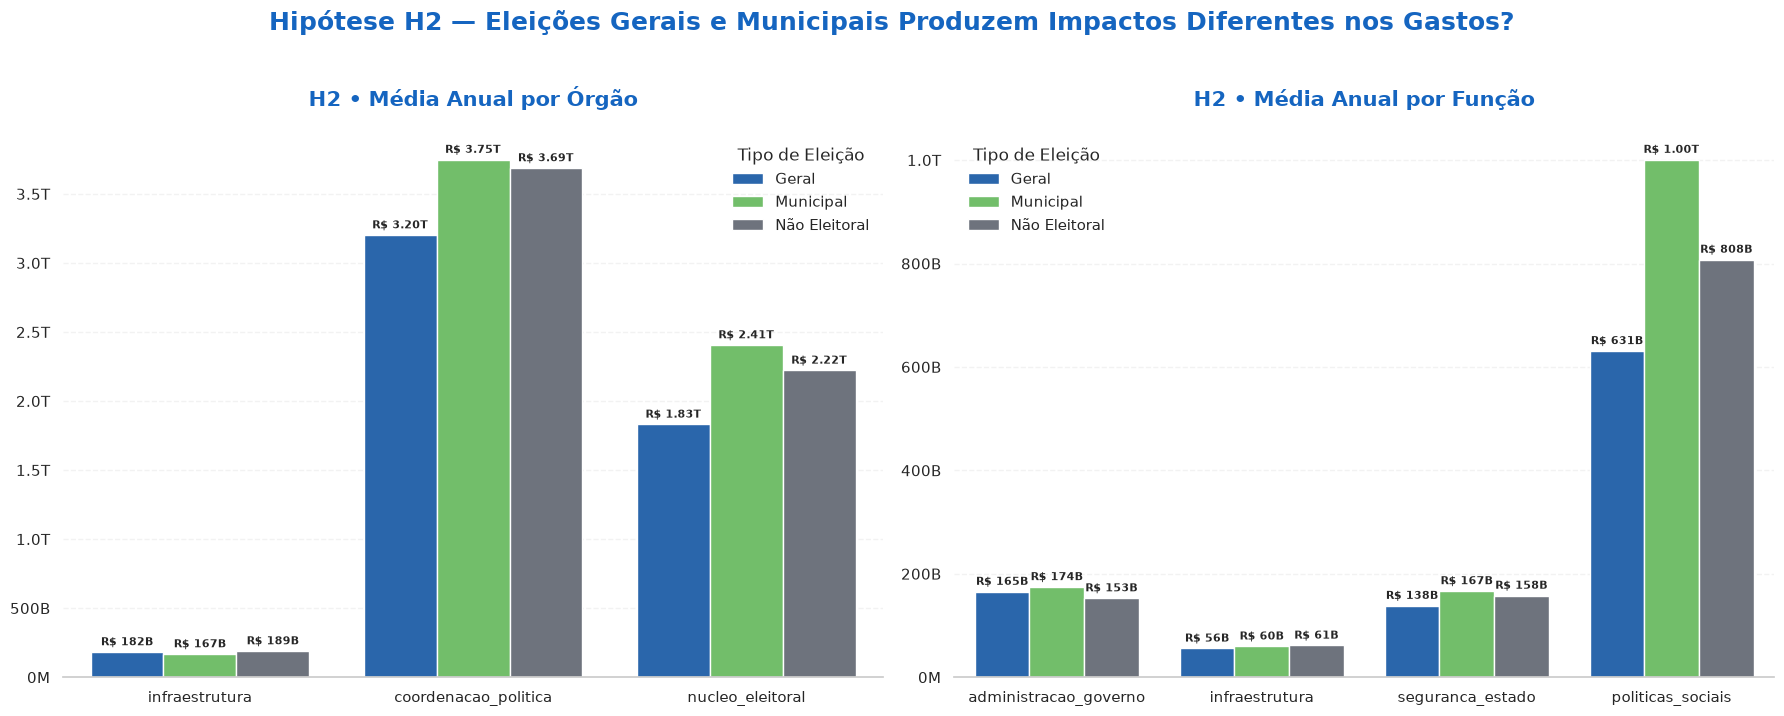

In [20]:
# ==========================
# DADOS H2
# ==========================

df_h2_orgao = con.sql("""
SELECT
    ano,
    pacote,
    TRIM(tipo_eleicao) AS tipo_eleicao,
    SUM(valor_pago) AS total_pago_ano
FROM ouro.despesas_por_orgao
WHERE ano < 2026
GROUP BY ano, pacote, TRIM(tipo_eleicao)
ORDER BY ano
""").df()

df_h2_funcao = con.sql("""
SELECT
    ano,
    pacote,
    TRIM(tipo_eleicao) AS tipo_eleicao,
    SUM(valor_pago) AS total_pago_ano
FROM ouro.despesas_funcional_programatica
WHERE ano < 2026
GROUP BY ano, pacote, TRIM(tipo_eleicao)
ORDER BY ano
""").df()

# Normaliza possíveis espaços ocultos
df_h2_orgao["tipo_eleicao"] = (
    df_h2_orgao["tipo_eleicao"]
    .astype(str)
    .str.strip()
)

df_h2_funcao["tipo_eleicao"] = (
    df_h2_funcao["tipo_eleicao"]
    .astype(str)
    .str.strip()
)

# ==========================
# PALETA DOS SLIDES
# ==========================

AZUL = "#1565C0"
VERDE = "#66CC5C"
CINZA = "#6B7280"

palette_h2 = [
    AZUL,   # Geral
    VERDE,  # Municipal
    CINZA   # Não Eleitoral
]

ordem_hue = [
    "Geral",
    "Municipal",
    "Não Eleitoral"
]

# ==========================
# FORMATADORES
# ==========================

def formatar_moeda(valor):
    if valor >= 1e12:
        return f"R$ {valor/1e12:.2f}T"
    elif valor >= 1e9:
        return f"R$ {valor/1e9:.0f}B"
    return f"R$ {valor/1e6:.0f}M"

def moeda_tick(x, pos):
    if x >= 1e12:
        return f"{x/1e12:.1f}T"
    elif x >= 1e9:
        return f"{x/1e9:.0f}B"
    return f"{x/1e6:.0f}M"

# ==========================
# FIGURA
# ==========================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    facecolor="white"
)

# ==========================
# ÓRGÃOS
# ==========================

sns.barplot(
    data=df_h2_orgao,
    x="pacote",
    y="total_pago_ano",
    hue="tipo_eleicao",
    hue_order=ordem_hue,
    estimator=np.mean,
    errorbar=None,
    palette=palette_h2,
    edgecolor="white",
    linewidth=1,
    ax=axes[0]
)

axes[0].set_title(
    "H2 • Média Anual por Órgão",
    fontsize=15,
    fontweight="bold",
    color=AZUL,
    pad=20
)

# ==========================
# FUNÇÕES
# ==========================

sns.barplot(
    data=df_h2_funcao,
    x="pacote",
    y="total_pago_ano",
    hue="tipo_eleicao",
    hue_order=ordem_hue,
    estimator=np.mean,
    errorbar=None,
    palette=palette_h2,
    edgecolor="white",
    linewidth=1,
    ax=axes[1]
)

axes[1].set_title(
    "H2 • Média Anual por Função",
    fontsize=15,
    fontweight="bold",
    color=AZUL,
    pad=20
)

# ==========================
# ESTILO
# ==========================

for ax in axes:

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.yaxis.set_major_formatter(
        FuncFormatter(moeda_tick)
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.legend(
        title="Tipo de Eleição",
        frameon=False
    )

    for container in ax.containers:

        labels = [
            formatar_moeda(bar.get_height())
            for bar in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=8,
            fontweight="bold"
        )

sns.despine(left=True)

plt.suptitle(
    "Hipótese H2 — Eleições Gerais e Municipais Produzem Impactos Diferentes nos Gastos?",
    fontsize=18,
    fontweight="bold",
    color=AZUL,
    y=1.02
)

plt.tight_layout()
plt.show()

### Resultado H2

Hipótese corroborada. O tipo de eleição mostrou maior capacidade explicativa do que a simples ocorrência de um ano eleitoral.

## 3. Transições de Governo e Prioridades Setoriais (H3)

Avaliamos aqui o comportamento acumulado dos pacotes sob a ótica das diferentes administrações federais (`governo`). O objetivo é identificar se a mudança de gestão altera a alocação de recursos nos pacotes estratégicos.

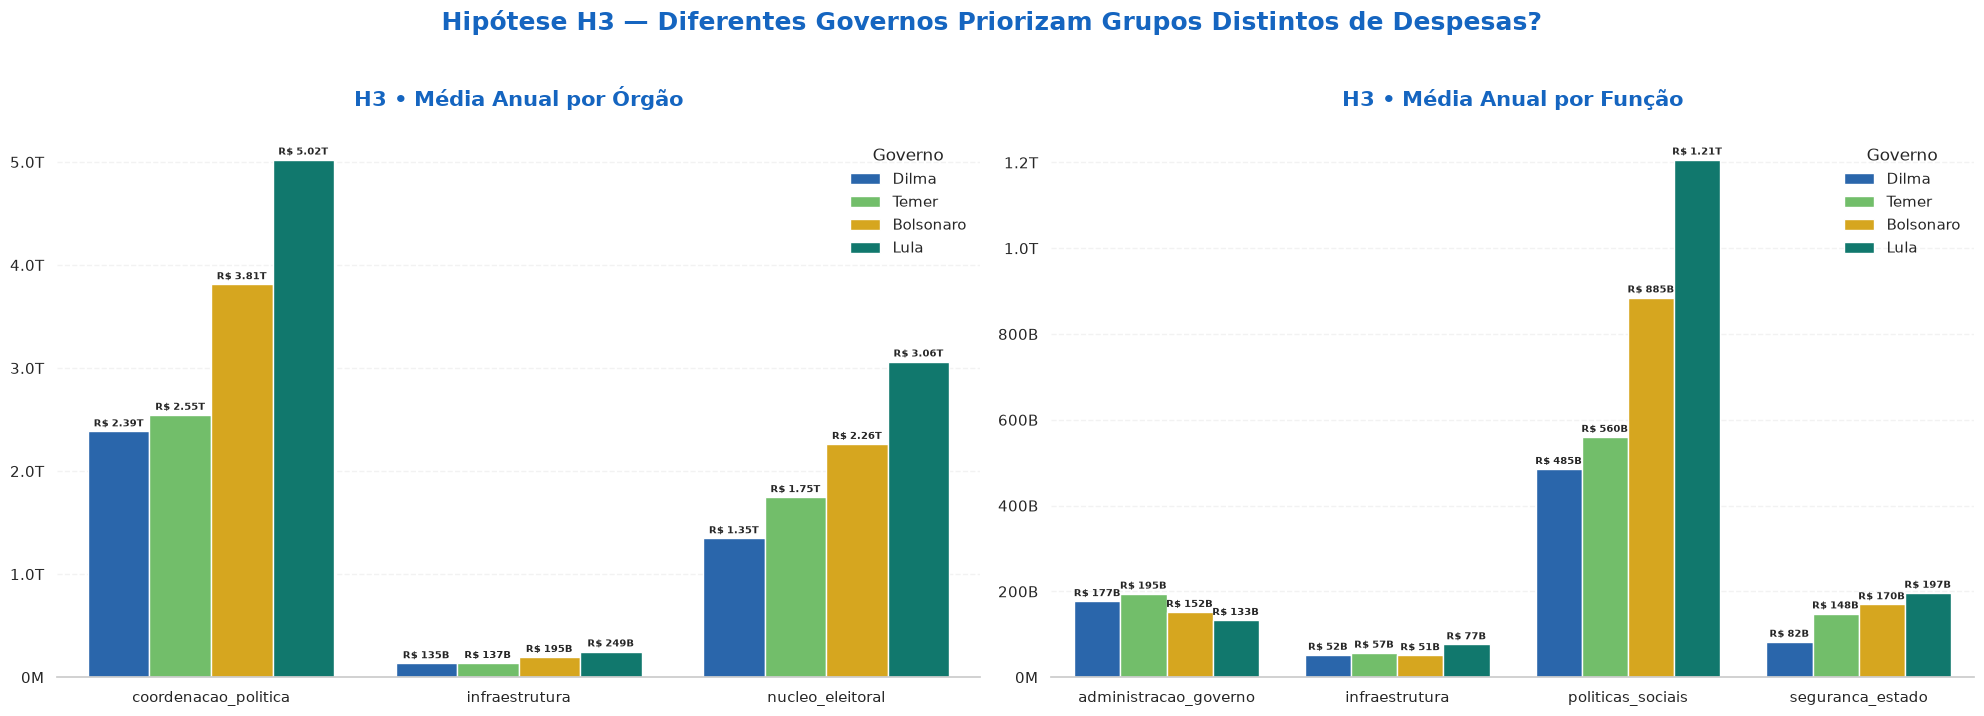

In [21]:
# ==========================
# DADOS 3
# ==========================

df_h3_orgao = con.sql("""
WITH base AS (

    SELECT
        CASE
            WHEN governo IN ('Dilma 1', 'Dilma 2') THEN 'Dilma'
            WHEN governo = 'Lula 3' THEN 'Lula'
            ELSE governo
        END AS governo,
        ano,
        pacote,
        SUM(valor_pago) AS total_pago_ano

    FROM ouro.despesas_por_orgao
    WHERE ano < 2026
      AND governo <> 'Transicao'

    GROUP BY 1, 2, 3
)

SELECT
    governo,
    pacote,
    AVG(total_pago_ano) AS media_anual
FROM base
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

df_h3_funcao = con.sql("""
WITH base AS (

    SELECT
        CASE
            WHEN governo IN ('Dilma 1', 'Dilma 2') THEN 'Dilma'
            WHEN governo = 'Lula 3' THEN 'Lula'
            ELSE governo
        END AS governo,
        ano,
        pacote,
        SUM(valor_pago) AS total_pago_ano

    FROM ouro.despesas_funcional_programatica
    WHERE ano < 2026
      AND governo <> 'Transicao'

    GROUP BY 1, 2, 3
)

SELECT
    governo,
    pacote,
    AVG(total_pago_ano) AS media_anual
FROM base
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

# ==========================
# PALETA
# ==========================

AZUL = "#1565C0"
VERDE = "#66CC5C"
AMARELO = "#F4B400"
VERDE_ESCURO = "#00897B"

palette_h3 = {
    "Dilma": AZUL,
    "Temer": VERDE,
    "Bolsonaro": AMARELO,
    "Lula": VERDE_ESCURO
}

ordem_governo = [
    "Dilma",
    "Temer",
    "Bolsonaro",
    "Lula"
]

# ==========================
# FORMATADORES
# ==========================

def moeda_tick(x, pos):

    if x >= 1e12:
        return f"{x/1e12:.1f}T"

    if x >= 1e9:
        return f"{x/1e9:.0f}B"

    return f"{x/1e6:.0f}M"


def formatar_moeda(valor):

    if pd.isna(valor) or valor == 0:
        return ""

    if valor >= 1e12:
        return f"R$ {valor/1e12:.2f}T"

    if valor >= 1e9:
        return f"R$ {valor/1e9:.0f}B"

    return f"R$ {valor/1e6:.0f}M"

# ==========================
# FIGURA
# ==========================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 7),
    facecolor="white"
)

# ==========================
# ÓRGÃOS
# ==========================

sns.barplot(
    data=df_h3_orgao,
    x="pacote",
    y="media_anual",
    hue="governo",
    hue_order=ordem_governo,
    errorbar=None,
    palette=palette_h3,
    edgecolor="white",
    linewidth=1,
    ax=axes[0]
)

axes[0].set_title(
    "H3 • Média Anual por Órgão",
    fontsize=15,
    fontweight="bold",
    color=AZUL,
    pad=20
)

# ==========================
# FUNÇÕES
# ==========================

sns.barplot(
    data=df_h3_funcao,
    x="pacote",
    y="media_anual",
    hue="governo",
    hue_order=ordem_governo,
    errorbar=None,
    palette=palette_h3,
    edgecolor="white",
    linewidth=1,
    ax=axes[1]
)

axes[1].set_title(
    "H3 • Média Anual por Função",
    fontsize=15,
    fontweight="bold",
    color=AZUL,
    pad=20
)

# ==========================
# ESTILO
# ==========================

for ax in axes:

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.yaxis.set_major_formatter(
        FuncFormatter(moeda_tick)
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.legend(
        title="Governo",
        frameon=False
    )

    # ==========================
    # RÓTULOS NAS BARRAS
    # ==========================

    for container in ax.containers:

        labels = [
            formatar_moeda(bar.get_height())
            for bar in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=2,
            fontsize=7,
            fontweight="bold"
        )

sns.despine(left=True)

plt.suptitle(
    "Hipótese H3 — Diferentes Governos Priorizam Grupos Distintos de Despesas?",
    fontsize=18,
    fontweight="bold",
    color=AZUL,
    y=1.02
)

plt.tight_layout()
plt.show()

### Resultado H3

Hipótese corroborada. Diferentes governos apresentaram padrões distintos de alocação de recursos.

## 4. Efeito Pós-Eleitoral (H4)

A hipótese H4 investiga se os anos imediatamente posteriores aos ciclos eleitorais apresentam uma desaceleração no crescimento das despesas públicas, refletindo um possível movimento de ajuste fiscal após períodos de maior expansão orçamentária.

Para avaliar esse comportamento, os registros foram segmentados entre anos classificados como **Pós-Eleitorais** (`fl_ano_pos_eleitoral = TRUE`) e anos **Comuns** (`FALSE`).

Como a variável `variacao_yoy_pct` apresentou valores extremos que distorciam as médias, optou-se pela utilização da **mediana da variação percentual anual (YoY)** como medida de tendência central. Essa abordagem reduz a influência de outliers e fornece uma representação mais robusta do comportamento típico das despesas.

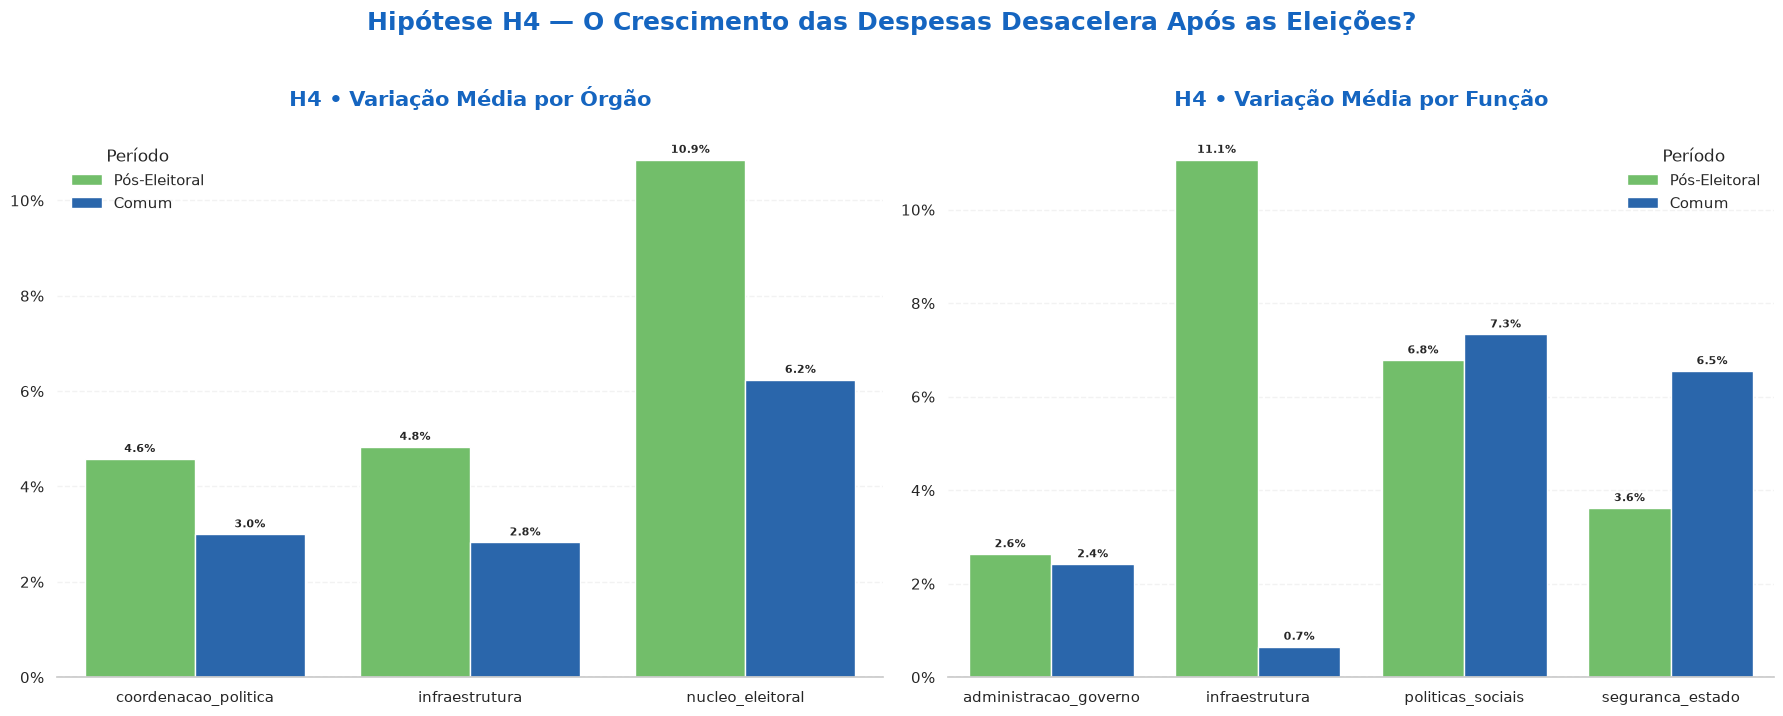

In [22]:
# ==========================
# DADOS H4
# ==========================

df_h4_orgao = con.sql("""
SELECT
    pacote,
    CASE
        WHEN fl_ano_pos_eleitoral
            THEN 'Pós-Eleitoral'
        ELSE 'Comum'
    END AS periodo,
    MEDIAN(variacao_yoy_pct) AS media_variacao_pct
FROM ouro.despesas_por_orgao
WHERE variacao_yoy_pct IS NOT NULL
  AND ano < 2026
GROUP BY pacote, periodo
ORDER BY pacote, periodo
""").df()

df_h4_funcao = con.sql("""
SELECT
    pacote,
    CASE
        WHEN fl_ano_pos_eleitoral
            THEN 'Pós-Eleitoral'
        ELSE 'Comum'
    END AS periodo,
    MEDIAN(variacao_yoy_pct) AS media_variacao_pct
FROM ouro.despesas_funcional_programatica
WHERE variacao_yoy_pct IS NOT NULL
  AND ano < 2026
GROUP BY pacote, periodo
ORDER BY pacote, periodo
""").df()

# ==========================
# PALETA PADRÃO DOS SLIDES
# ==========================

AZUL = "#1565C0"
VERDE = "#66CC5C"
CINZA = "#6B7280"

palette_h4 = {
    "Pós-Eleitoral": VERDE,
    "Comum": AZUL
}

ordem_periodo = [
    "Pós-Eleitoral",
    "Comum"
]

# ==========================
# FORMATADORES
# ==========================

def formatar_pct(valor):

    if pd.isna(valor):
        return ""

    return f"{valor:.1f}%"


def percentual_tick(x, pos):
    return f"{x:.0f}%"

# ==========================
# FIGURA
# ==========================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    facecolor="white"
)

# ==========================
# ÓRGÃOS
# ==========================

sns.barplot(
    data=df_h4_orgao,
    x="pacote",
    y="media_variacao_pct",
    hue="periodo",
    hue_order=ordem_periodo,
    errorbar=None,
    palette=palette_h4,
    edgecolor="white",
    linewidth=1,
    ax=axes[0]
)

axes[0].set_title(
    "H4 • Variação Média por Órgão",
    fontsize=15,
    fontweight="bold",
    color=AZUL,
    pad=20
)

# ==========================
# FUNÇÕES
# ==========================

sns.barplot(
    data=df_h4_funcao,
    x="pacote",
    y="media_variacao_pct",
    hue="periodo",
    hue_order=ordem_periodo,
    errorbar=None,
    palette=palette_h4,
    edgecolor="white",
    linewidth=1,
    ax=axes[1]
)

axes[1].set_title(
    "H4 • Variação Média por Função",
    fontsize=15,
    fontweight="bold",
    color=AZUL,
    pad=20
)

# ==========================
# ESTILO
# ==========================

for ax in axes:

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.yaxis.set_major_formatter(
        FuncFormatter(percentual_tick)
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    # Linha zero para destacar
    # acelerações e desacelerações
    ax.axhline(
        0,
        color=CINZA,
        linewidth=1,
        linestyle="--",
        alpha=0.7
    )

    ax.legend(
        title="Período",
        frameon=False
    )

    # ==========================
    # RÓTULOS NAS BARRAS
    # ==========================

    for container in ax.containers:

        labels = [
            formatar_pct(bar.get_height())
            for bar in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=8,
            fontweight="bold"
        )

sns.despine(left=True)

plt.suptitle(
    "Hipótese H4 — O Crescimento das Despesas Desacelera Após as Eleições?",
    fontsize=18,
    fontweight="bold",
    color=AZUL,
    y=1.02
)

plt.tight_layout()
plt.show()

### Resultado H4

Hipótese parcialmente corroborada. A desaceleração pós-eleitoral ocorre em grupos específicos, mas não em toda a administração pública.

## 5. Concentração dos Gastos em Grupos Estratégicos (H5)

A hipótese H5 investiga se os ciclos eleitorais influenciam não apenas o volume total de gastos, mas também a forma como os recursos são distribuídos entre diferentes grupos de despesas.

Enquanto as hipóteses anteriores analisaram variações no montante gasto, esta etapa busca identificar possíveis mudanças na **composição orçamentária**, verificando se determinados grupos passam a representar uma parcela maior do orçamento durante períodos eleitorais.

O foco está nos grupos com maior potencial de impacto político e social, tais como:

- Núcleo Eleitoral;
- Coordenação Política;
- Políticas Sociais.

Para cada ano, será calculada a participação relativa de cada grupo em relação ao total de despesas executadas, permitindo comparar sua representatividade em:

- Anos Eleitorais;
- Anos Não Eleitorais;
- Eleições Gerais;
- Eleições Municipais.

A hipótese parte da premissa de que gestores públicos podem alterar a composição dos gastos em períodos eleitorais, direcionando uma parcela maior dos recursos para áreas com maior visibilidade junto à população ou maior relevância estratégica para o ciclo político.

A análise busca responder à seguinte questão:

> A participação relativa dos grupos com maior potencial de impacto político aumenta durante os ciclos eleitorais?

Caso confirmada, a hipótese indicará que os ciclos eleitorais afetam não apenas o volume de gastos públicos, mas também a forma como os recursos são distribuídos entre diferentes prioridades governamentais.

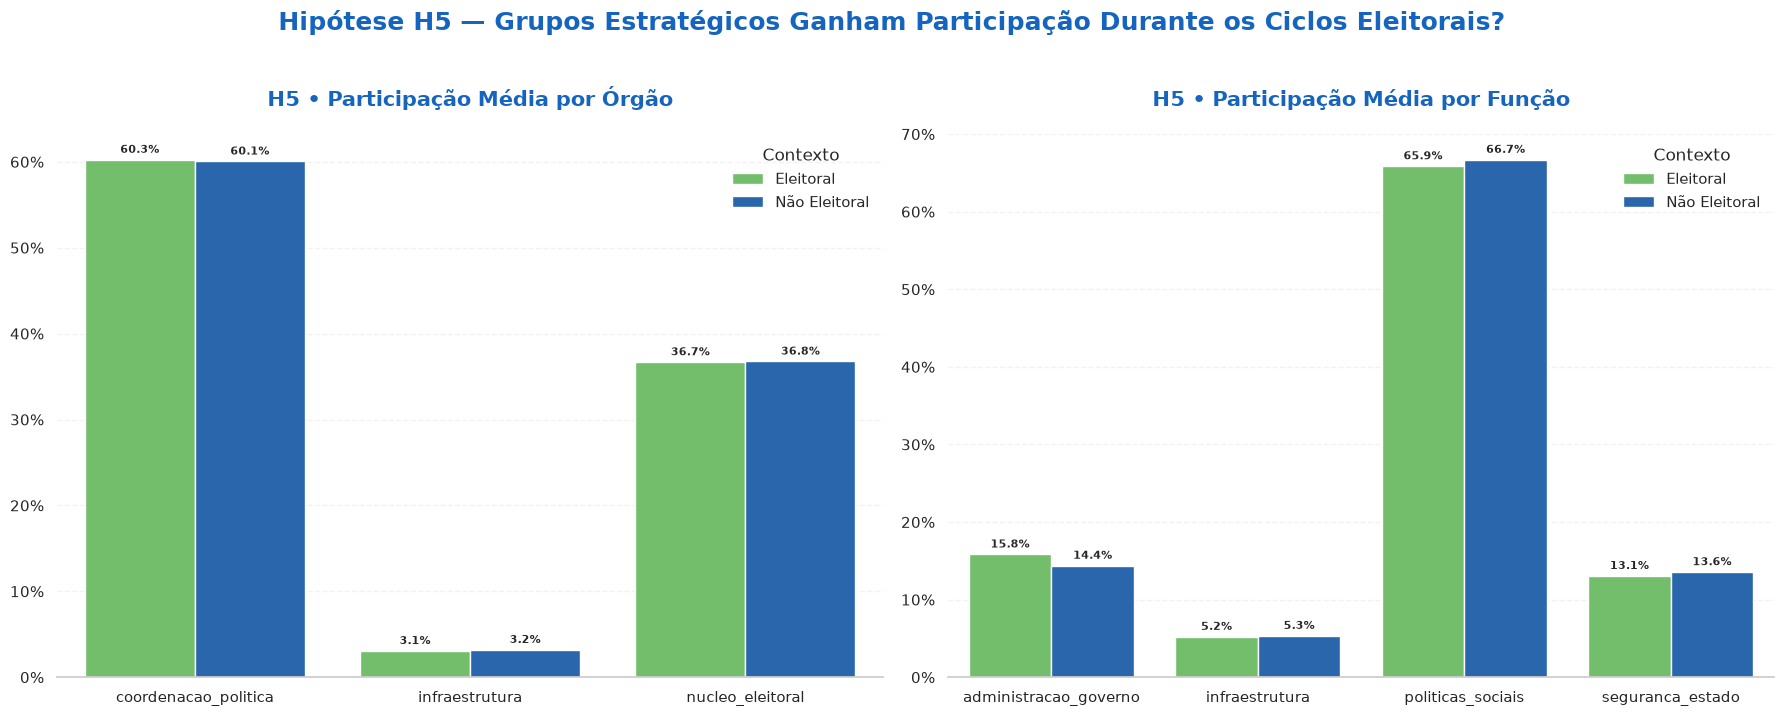

In [23]:
# ==========================
# DADOS H5
# ==========================

df_h5_orgao = con.sql("""
WITH base AS (

    SELECT
        ano,
        pacote,
        CASE
            WHEN tipo_eleicao IN ('Geral', 'Municipal')
                THEN 'Eleitoral'
            ELSE 'Não Eleitoral'
        END AS contexto,
        SUM(valor_pago) AS total_pago
    FROM ouro.despesas_por_orgao
    WHERE ano < 2026
    GROUP BY ano, pacote, contexto

),

totais AS (

    SELECT
        ano,
        contexto,
        SUM(total_pago) AS total_ano
    FROM base
    GROUP BY ano, contexto

)

SELECT
    b.pacote,
    b.contexto,
    AVG(
        (b.total_pago / t.total_ano) * 100
    ) AS participacao_pct
FROM base b
INNER JOIN totais t
    ON b.ano = t.ano
   AND b.contexto = t.contexto
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

df_h5_funcao = con.sql("""
WITH base AS (

    SELECT
        ano,
        pacote,
        CASE
            WHEN tipo_eleicao IN ('Geral', 'Municipal')
                THEN 'Eleitoral'
            ELSE 'Não Eleitoral'
        END AS contexto,
        SUM(valor_pago) AS total_pago
    FROM ouro.despesas_funcional_programatica
    WHERE ano < 2026
    GROUP BY ano, pacote, contexto

),

totais AS (

    SELECT
        ano,
        contexto,
        SUM(total_pago) AS total_ano
    FROM base
    GROUP BY ano, contexto

)

SELECT
    b.pacote,
    b.contexto,
    AVG(
        (b.total_pago / t.total_ano) * 100
    ) AS participacao_pct
FROM base b
INNER JOIN totais t
    ON b.ano = t.ano
   AND b.contexto = t.contexto
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

# ==========================
# PALETA PADRÃO
# ==========================

AZUL = "#1565C0"
VERDE = "#66CC5C"
CINZA = "#6B7280"

palette_h5 = {
    "Eleitoral": VERDE,
    "Não Eleitoral": AZUL
}

ordem_contexto = [
    "Eleitoral",
    "Não Eleitoral"
]

# ==========================
# FORMATADORES
# ==========================

def percentual_tick(x, pos):
    return f"{x:.0f}%"

def formatar_pct(valor):

    if pd.isna(valor):
        return ""

    return f"{valor:.1f}%"

# ==========================
# FIGURA
# ==========================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    facecolor="white"
)

# ==========================
# ÓRGÃOS
# ==========================

sns.barplot(
    data=df_h5_orgao,
    x="pacote",
    y="participacao_pct",
    hue="contexto",
    hue_order=ordem_contexto,
    errorbar=None,
    palette=palette_h5,
    edgecolor="white",
    linewidth=1,
    ax=axes[0]
)

axes[0].set_title(
    "H5 • Participação Média por Órgão",
    fontsize=15,
    fontweight="bold",
    color=AZUL,
    pad=20
)

# ==========================
# FUNÇÕES
# ==========================

sns.barplot(
    data=df_h5_funcao,
    x="pacote",
    y="participacao_pct",
    hue="contexto",
    hue_order=ordem_contexto,
    errorbar=None,
    palette=palette_h5,
    edgecolor="white",
    linewidth=1,
    ax=axes[1]
)

axes[1].set_title(
    "H5 • Participação Média por Função",
    fontsize=15,
    fontweight="bold",
    color=AZUL,
    pad=20
)

# ==========================
# ESTILO
# ==========================

for ax in axes:

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.yaxis.set_major_formatter(
        FuncFormatter(percentual_tick)
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.legend(
        title="Contexto",
        frameon=False
    )

    for container in ax.containers:

        labels = [
            formatar_pct(bar.get_height())
            for bar in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=8,
            fontweight="bold"
        )

sns.despine(left=True)

plt.suptitle(
    "Hipótese H5 — Grupos Estratégicos Ganham Participação Durante os Ciclos Eleitorais?",
    fontsize=18,
    fontweight="bold",
    color=AZUL,
    y=1.02
)

plt.tight_layout()
plt.show()

### Resultado H5

Hipótese rejeitada. A composição relativa do orçamento permaneceu estável entre anos eleitorais e não eleitorais.

## Validação de Consistência Orçamentária

Além das análises exploratórias e da validação das hipóteses, foi realizada uma etapa de validação da consistência dos dados com o objetivo de identificar possíveis anomalias nos registros orçamentários utilizados ao longo do estudo.

A verificação concentrou-se em uma regra básica da execução orçamentária pública:

> O valor pago não deveria exceder o valor empenhado dentro do mesmo agrupamento analisado.

Em termos operacionais, foram identificados registros que atendiam à condição:

```sql
valor_pago > valor_empenhado
```

Embora essa situação possa indicar inconsistências em determinados contextos, sua interpretação exige cautela quando aplicada a dados agregados. Na execução orçamentária federal, é comum que pagamentos realizados em um exercício estejam associados a empenhos emitidos em anos anteriores, especialmente em decorrência da execução de restos a pagar e de compromissos plurianuais.

Por esse motivo, a presença de ocorrências em que o valor pago supera o valor empenhado não representa necessariamente uma irregularidade ou erro nos dados.

A análise foi aplicada sobre toda a base histórica utilizada no estudo, abrangendo diferentes órgãos, funções orçamentárias e períodos de governo.

O objetivo desta etapa não é testar uma hipótese comportamental, mas avaliar a confiabilidade dos dados utilizados nas análises estatísticas e nos modelos preditivos desenvolvidos ao longo do trabalho.

### Questão de Validação

> Existem ocorrências em que o valor pago supera o valor empenhado no mesmo agrupamento analisado e, em caso positivo, elas representam inconsistências relevantes para o estudo?


In [24]:
# ==========================
# ÓRGÃOS
# ==========================

df_anomalias_orgao = con.sql("""
SELECT
    ano,
    governo,
    nome_orgao AS entidade,
    pacote,
    valor_pago,
    valor_empenhado,
    (valor_pago - valor_empenhado) AS diferenca
FROM ouro.despesas_por_orgao
WHERE valor_pago > valor_empenhado
ORDER BY diferenca DESC
""").df()

# ==========================
# FUNÇÕES
# ==========================

df_anomalias_funcao = con.sql("""
SELECT
    ano,
    governo,
    nome_funcao AS entidade,
    pacote,
    valor_pago,
    valor_empenhado,
    (valor_pago - valor_empenhado) AS diferenca
FROM ouro.despesas_funcional_programatica
WHERE valor_pago > valor_empenhado
ORDER BY diferenca DESC
""").df()

# ==========================
# MÉTRICAS AUXILIARES
# ==========================

if not df_anomalias_orgao.empty:

    df_anomalias_orgao["pct_excedente"] = (
        df_anomalias_orgao["diferenca"]
        / df_anomalias_orgao["valor_empenhado"]
    ) * 100

if not df_anomalias_funcao.empty:

    df_anomalias_funcao["pct_excedente"] = (
        df_anomalias_funcao["diferenca"]
        / df_anomalias_funcao["valor_empenhado"]
    ) * 100

# ==========================
# SUMÁRIO EXECUTIVO
# ==========================

qtd_orgao = len(df_anomalias_orgao)
qtd_funcao = len(df_anomalias_funcao)

qtd_total = qtd_orgao + qtd_funcao

valor_excedente_orgao = (
    df_anomalias_orgao["diferenca"].sum()
    if qtd_orgao > 0 else 0
)

valor_excedente_funcao = (
    df_anomalias_funcao["diferenca"].sum()
    if qtd_funcao > 0 else 0
)

print("=" * 90)
print("⚡ VALIDAÇÃO DE CONSISTÊNCIA ORÇAMENTÁRIA")
print("=" * 90)

print(f"\nOcorrências identificadas (Órgãos): {qtd_orgao}")
print(f"Ocorrências identificadas (Funções): {qtd_funcao}")

if qtd_total == 0:

    print("\n RESULTADO DA VALIDAÇÃO")

    print(
        "Nenhum registro apresentou valor_pago "
        "superior ao valor_empenhado."
    )

    print(
        "\nConclusão: a base está aderente à regra "
        "orçamentária analisada."
    )

else:

    print("\n RESULTADO DA VALIDAÇÃO")

    print(
        "Foram identificadas ocorrências em que "
        "o valor pago superou o valor empenhado "
        "no agrupamento analisado."
    )

    print(
        f"\nExcedente acumulado (Órgãos): "
        f"R$ {valor_excedente_orgao:,.2f}"
    )

    print(
        f"Excedente acumulado (Funções): "
        f"R$ {valor_excedente_funcao:,.2f}"
    )

# ==========================
# DETALHAMENTO
# ==========================

if qtd_orgao > 0:

    print("\n VISÃO POR ÓRGÃOS")

    display(
        df_anomalias_orgao.assign(
            valor_pago_milhoes=lambda x: x["valor_pago"] / 1e6,
            valor_empenhado_milhoes=lambda x: x["valor_empenhado"] / 1e6,
            diferenca_milhoes=lambda x: x["diferenca"] / 1e6
        )[[
            "ano",
            "governo",
            "entidade",
            "pacote",
            "valor_pago_milhoes",
            "valor_empenhado_milhoes",
            "diferenca_milhoes",
            "pct_excedente"
        ]]
    )

if qtd_funcao > 0:

    print("\n VISÃO FUNCIONAL")

    display(
        df_anomalias_funcao.assign(
            valor_pago_milhoes=lambda x: x["valor_pago"] / 1e6,
            valor_empenhado_milhoes=lambda x: x["valor_empenhado"] / 1e6,
            diferenca_milhoes=lambda x: x["diferenca"] / 1e6
        )[[
            "ano",
            "governo",
            "entidade",
            "pacote",
            "valor_pago_milhoes",
            "valor_empenhado_milhoes",
            "diferenca_milhoes",
            "pct_excedente"
        ]]
    )

# ==========================
# CONCLUSÃO AUTOMÁTICA
# ==========================

print("\n CONCLUSÃO")

if qtd_total == 0:

    print(
        "Não foram identificadas ocorrências em que "
        "o valor pago superasse o valor empenhado. "
        "Os dados apresentaram aderência à regra "
        "de consistência analisada."
    )

else:

    print(
        "Foram identificadas ocorrências pontuais em que "
        "o valor pago superou o valor empenhado dentro do "
        "mesmo agrupamento analisado."
    )

    print(
        "\nComo a validação foi realizada sobre dados "
        "agregados por exercício, não é possível determinar "
        "a origem exata dessas diferenças apenas com as "
        "informações disponíveis."
    )

    print(
        "\nAs ocorrências observadas não configuram, por si só, "
        "evidência de inconsistência dos dados, mas indicam casos "
        "que exigiriam investigação adicional em nível transacional "
        "para identificação da causa específica."
    )

    print(
        "\nApesar disso, a baixa quantidade de ocorrências "
        "identificadas e sua concentração em poucos agrupamentos "
        "não sugerem a existência de problemas sistêmicos capazes "
        "de comprometer as análises realizadas neste estudo."
    )

⚡ VALIDAÇÃO DE CONSISTÊNCIA ORÇAMENTÁRIA

Ocorrências identificadas (Órgãos): 1
Ocorrências identificadas (Funções): 2

 RESULTADO DA VALIDAÇÃO
Foram identificadas ocorrências em que o valor pago superou o valor empenhado no agrupamento analisado.

Excedente acumulado (Órgãos): R$ 18,959.00
Excedente acumulado (Funções): R$ 44,442,776,912.14

 VISÃO POR ÓRGÃOS


,ano,governo,entidade,pacote,valor_pago_milhoes,valor_empenhado_milhoes,diferenca_milhoes,pct_excedente
0,2024,Lula 3,Fundo de Estabilidade do Seguro Rural,coordenacao_politica,37.61,37.59,0.02,0.05



 VISÃO FUNCIONAL


,ano,governo,entidade,pacote,valor_pago_milhoes,valor_empenhado_milhoes,diferenca_milhoes,pct_excedente
0,2017,Temer,Assistência social,politicas_sociais,166184.82,141111.28,25073.54,17.77
1,2015,Dilma 2,Assistência social,politicas_sociais,138379.57,119010.34,19369.23,16.28



 CONCLUSÃO
Foram identificadas ocorrências pontuais em que o valor pago superou o valor empenhado dentro do mesmo agrupamento analisado.

Como a validação foi realizada sobre dados agregados por exercício, não é possível determinar a origem exata dessas diferenças apenas com as informações disponíveis.

As ocorrências observadas não configuram, por si só, evidência de inconsistência dos dados, mas indicam casos que exigiriam investigação adicional em nível transacional para identificação da causa específica.

Apesar disso, a baixa quantidade de ocorrências identificadas e sua concentração em poucos agrupamentos não sugerem a existência de problemas sistêmicos capazes de comprometer as análises realizadas neste estudo.


Foram identificadas duas ocorrências materialmente relevantes na função Assistência Social, nas quais o valor pago superou o valor empenhado em aproximadamente 16% e 18%, respectivamente.

Como a análise foi realizada sobre dados agregados por exercício, não foi possível determinar a origem exata dessas diferenças. Uma possível explicação envolve mecanismos de execução interanual do orçamento, como restos a pagar ou pagamentos vinculados a empenhos emitidos em exercícios anteriores.

Apesar disso, as ocorrências foram pontuais e concentradas em apenas dois exercícios, não caracterizando evidência de inconsistência sistêmica na base analisada.

## Conclusão

### Principais Evidências Identificadas

A análise demonstrou que variáveis político-eleitorais exercem influência relevante sobre o comportamento das despesas públicas federais, embora seus efeitos ocorram de forma heterogênea entre diferentes grupos orçamentários.

#### H1 — Efeito Eleitoral Geral

Não foram identificadas evidências robustas de aumento generalizado dos gastos apenas pela ocorrência de um ano eleitoral. Os volumes médios observados permaneceram relativamente estáveis entre períodos eleitorais e não eleitorais.

#### H2 — Tipo de Eleição

O tipo de eleição mostrou-se mais relevante do que a simples existência do ciclo eleitoral. As eleições municipais apresentaram forte associação com o aumento dos gastos em políticas sociais e grupos relacionados à execução local de políticas públicas.

#### H3 — Mudança de Governo

As diferentes administrações federais apresentaram padrões distintos de alocação de recursos, indicando que a variável governo possui capacidade explicativa relevante para compreender a evolução das despesas ao longo do tempo.

#### H4 — Efeito Pós-Eleitoral

Foi observada desaceleração do crescimento em grupos associados ao núcleo eleitoral e às políticas públicas finalísticas. Entretanto, esse comportamento não ocorreu de forma uniforme em toda a administração pública, sugerindo ajustes seletivos e não um ajuste fiscal generalizado.

#### H5 — Concentração dos Gastos

A composição relativa do orçamento apresentou elevada estabilidade ao longo da série histórica. Não foram encontradas evidências consistentes de aumento da participação dos grupos estratégicos durante períodos eleitorais.

#### Validação de Consistência

A auditoria identificou poucas ocorrências em que o valor pago superou o valor empenhado. Embora duas delas apresentem magnitude relevante, sua baixa frequência não sugere problemas sistêmicos de qualidade dos dados.

### Implicações para o Modelo Preditivo

Os resultados reforçam a relevância das variáveis políticas e institucionais como atributos explicativos do comportamento orçamentário.

Em particular, as variáveis `governo`, `tipo_eleicao`, `fl_ano_eleitoral`, `fl_ano_pos_eleitoral`, bem como os atributos temporais derivados da série histórica, demonstram potencial para melhorar a capacidade preditiva dos modelos de Machine Learning que serão desenvolvidos no Notebook 3.

Dessa forma, a camada Ouro construída no Lakehouse demonstrou não apenas consistência técnica, mas também capacidade de gerar informações analíticas úteis para previsão e interpretação dos gastos públicos federais.
